# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [620]:
STUDENT_NAME = "Dương Gia Bảo"  # TODO: Họ và tên
STUDENT_ID = "2550013"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Dương Gia Bảo (2550013)


In [621]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\Crink\Documents\HỌC ML\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [622]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [623]:
# TODO N1

shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits/np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

In [624]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [625]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [626]:
# TODO N2
train_feature_mean = X_train.mean(axis=0)
train_feature_std = X_train.std(axis=0)
X_train_scaled = (X_train-train_feature_mean)/train_feature_std
X_val_scaled = (X_val-X_val.mean(axis=0))/X_val.std(axis=0)

In [627]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [628]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [629]:
# TODO N3
correct_mask = predicted_classes == true_labels
high_confidence_mask = confidence_scores > confidence_threshold
review_mask = ~correct_mask | ~high_confidence_mask
review_indices = [i       for i, x in enumerate(review_mask) if x]
print( review_indices)

[0, 1, 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [630]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [631]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32)/(2*4*4*3)
augmented_batch = normalized_batch.copy()[:,:,::-1,:]
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->
1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.
2. Giá trị thiếu trong `automobile_raw.csv` được giữ dưới dạng ký hiệu `?`.
3. symboling nghĩa là "Mức đánh giá rủi ro bảo hiểm"

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [632]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == "?").sum().sum()


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [633]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [634]:
# TODO D2
df_clean = raw_df.replace("?",np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
missing_by_column = df_clean.isna().sum()
print(missing_by_column)

symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 4
dtype: int64


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
Không nên fill tất cả numeric colums bằng cùng 1 giá trị bởi vì mỗi cột là một loại dữ liệu, có nghĩa là mỗi cột nó có một đơn vị riêng hoặc là một định dạng (chữ hoặc là số).
Xét dataset đã cho, thì `price` chỉ thiếu có 4 giá trị (không đáng kể so với dataset), vì vậy có thể dự đoán giá trị và fill vào cho giá trị của price
-> Nên fill
`normalized_losses` bị thiếu quá nhiều dữ liệu, dẫn đến việc thông tin bị mờ, dữ liệu bị nhiễu, dẫn đến việc không thể dự đoán dữ liệu và fill vào được.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [635]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [636]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna()

X_auto = analysis_df.to_numpy()

auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)

X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [637]:
# TODO D4
price_index = 25
price_z = (df_clean["price"] - df_clean["price"].mean())/df_clean["price"].std()
price_outlier_mask = abs(price_z)>2
price_outliers = [i for i,m in enumerate(price_outlier_mask) if m]


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [638]:
# TODO D5
engine_price_corr = df_clean["engine_size"].corr(df_clean["price"])
price_by_body_style = df_clean.groupby("body_style")["price"].mean().sort_index()
print(price_by_body_style)

body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

<Axes: xlabel='price', ylabel='Count'>

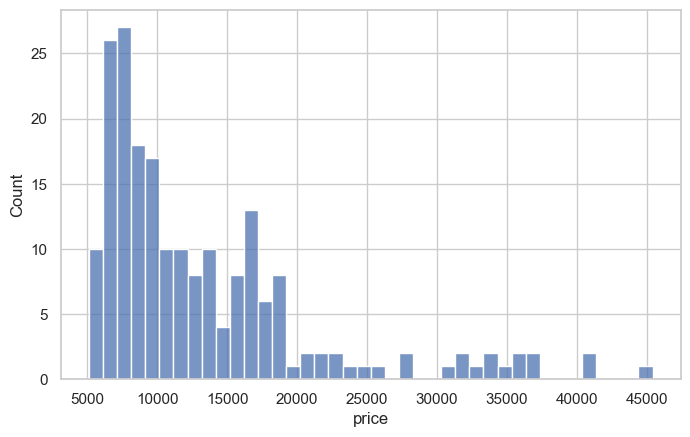

In [648]:
# TODO M2.1: histogram/KDE của price
sns.histplot(df_clean["price"],bins=40)

**Nhận xét:** Phân phối lệch phải, tập trung dày đặc từ 5000-15000

## M2.2 Dataset có cân bằng theo body style không?

<Axes: xlabel='count', ylabel='body_style'>

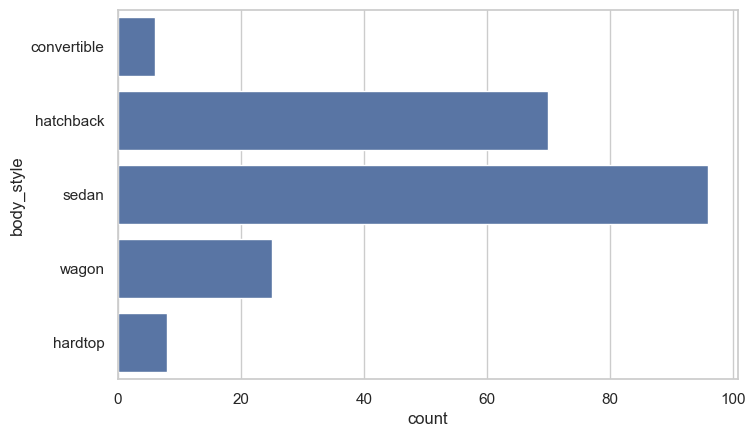

In [640]:
# TODO M2.2: countplot của body_style
sns.countplot(df_clean["body_style"])

**Nhận xét:** Dataset không cân bằng theo body_style, bởi vì sedan và hatchback chiếm đa số-> mô hình bị bias

## M2.3 Price khác nhau theo body style ra sao?

<Axes: xlabel='body_style', ylabel='price'>

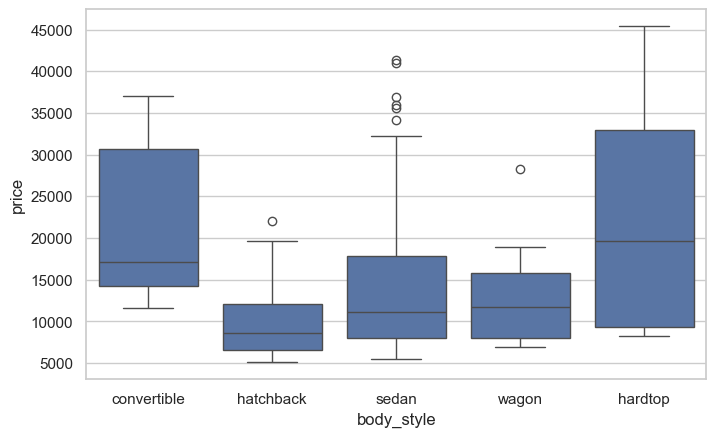

In [641]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(x=df_clean["body_style"],y=df_clean["price"])

**Nhận xét:** convertible định vị ở phân khúc giá cao, trong khi hatback, sedan và wagon được phân vào các lớp phân khúc giá thấp. Trong khi đó, hardtop có sự đa dạng về phân khúc (trải dài từ phân khúc thấp đến cao)

## M2.4 Engine size liên quan thế nào tới price?

<Axes: xlabel='engine_size', ylabel='price'>

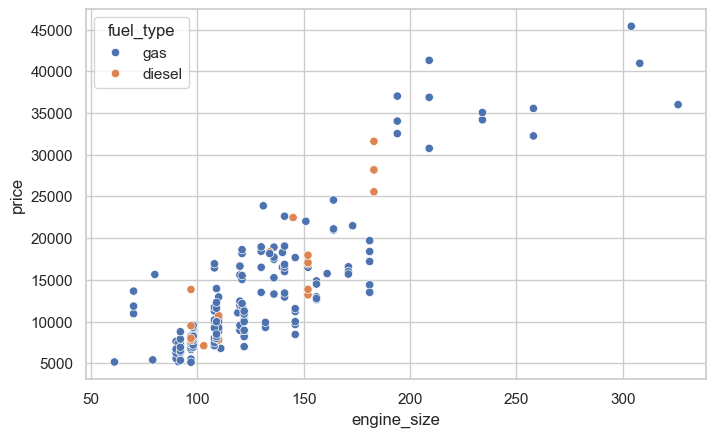

In [642]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
sns.scatterplot(
    data=df_clean, 
    x="engine_size", 
    y="price", 
    hue="fuel_type"
)

**Nhận xét:** Biểu đồ thể hiện một mối tương quan thuận giữa kích thước động cơ (engine_size) và giá cả (price), cho thấy đây là một đặc trưng tuyến tính có giá trị cao cho các mô hình hồi quy. Đối với biến phân loại fuel_type, các mẫu xe sử dụng nhiên liệu gas chiếm đại đa số và trải dài trên toàn bộ dải dữ liệu, trong khi nhóm xe diesel xuất hiện thưa thớt hơn và tập trung chủ yếu ở phân khúc động cơ vừa và nhỏ (từ dưới 100 đến dưới 200)

## M2.5 Các feature numeric tương quan ra sao?

<Axes: >

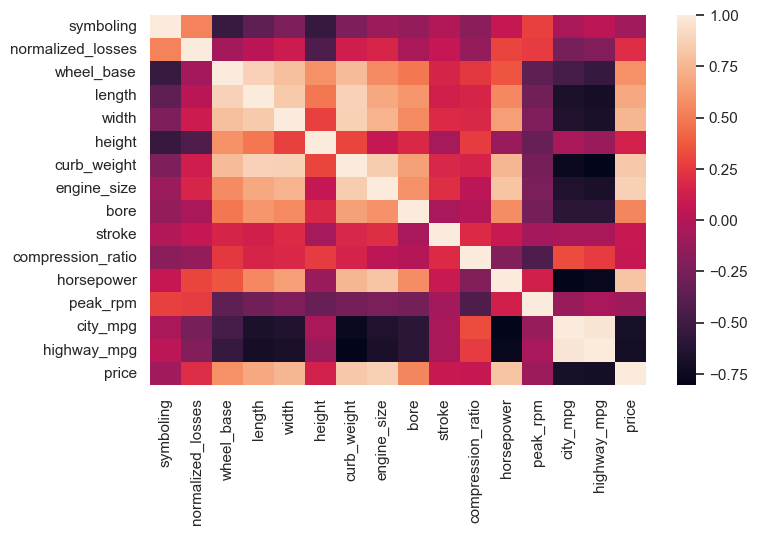

In [643]:
# TODO M2.5: correlation heatmap
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr)

**Nhận xét:** Biểu đồ heatmap chỉ ra hiện tượng đa cộng tuyến (multicollinearity) nghiêm trọng giữa các đặc trưng kích thước và khối lượng xe như wheel_base, length, width, và curb_weight (tương quan thuận rất mạnh, tiến gần mức $1.0$), điều này đòi hỏi phải áp dụng các kỹ thuật giảm chiều dữ liệu hoặc loại bỏ bớt biến để tránh làm nhiễu mô hình hồi quy. Đối với biến mục tiêu price, các thuộc tính bao gồm curb_weight, engine_size, và horsepower thể hiện mối tương quan thuận mạnh mẽ nhất; trái lại, hai biến city_mpg và highway_mpg lại cho thấy mối tương quan nghịch rõ rệt với giá xe.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.
## horsepower có tương quan gì với price?

<Axes: xlabel='horsepower', ylabel='price'>

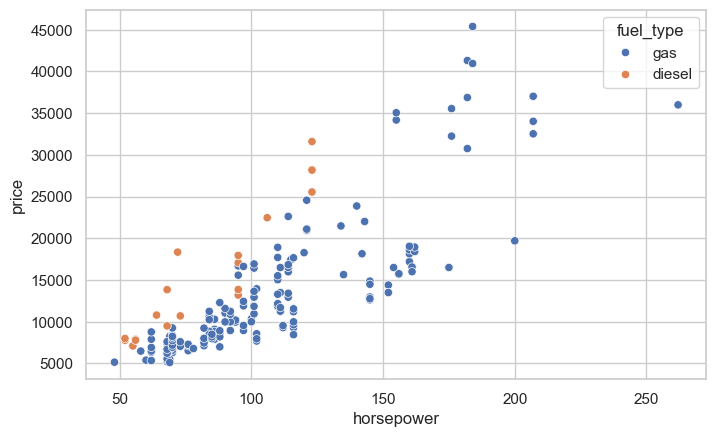

In [651]:
# TODO M2.6: biểu đồ tự chọn
sns.scatterplot(data=df_clean,x= "horsepower",y= "price",hue="fuel_type")

**Nhận xét:** Dựa vào đồ thị thì thấy được rằng công suất động cơ góp phần đẩy giá của xe lên cao, các mẫu xe chạy bằng diesel không có công suất cao bằng các mẫu xe chạy bằng gas

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

Dựa trên kết quả phân tích trực quan hóa dữ liệu, nghiên cứu đã xác định được các quy luật phân phối và mối quan hệ đặc trưng cốt lõi tác động đến giá xe (price). Biến mục tiêu có xu hướng lệch phải rõ rệt và xuất hiện nhiều giá trị ngoại lai cao cấp từ $30,000 đến $45,000. Trong đó, cấu hình kỹ thuật bao gồm kích thước động cơ (engine_size) và mã lực (horsepower) thể hiện mối tương quan thuận mạnh mẽ nhất với giá thành. Xét theo biến phân loại, kiểu dáng xe (body_style) thuộc nhóm convertible và hardtop định vị hoàn toàn ở phân khúc giá cao; đồng thời các dòng xe sử dụng nhiên liệu diesel cũng ghi nhận mức giá sàn nhỉnh hơn so với xe chạy xăng (gas) ở cùng tầm hiệu năng. Tuy nhiên, tập dữ liệu vẫn tồn tại hai hạn chế lớn cần lưu ý trước khi đưa vào huấn luyện mô hình. Thứ nhất là hiện tượng mất cân bằng phân lớp nghiêm trọng (Class Imbalance) khi các nhóm đa số như sedan, hatchback và hệ thống động cơ gas chiếm tỷ trọng áp đảo. Thứ hai là hiện tượng đa cộng tuyến (Multicollinearity) phức tạp giữa các đặc trưng vật lý của xe trên biểu đồ Heatmap. Để tối ưu hóa hiệu năng dự đoán và giảm thiểu độ chệch (bias) cho các mô hình học máy trong các bước tiếp theo, nghiên cứu đề xuất áp dụng kỹ thuật Log Transformation cho biến price, đồng thời thực hiện giảm chiều dữ liệu hoặc lựa chọn lại đặc trưng (Feature Selection) để loại bỏ các biến trùng lặp.